# Churn Model — XGBoost Calibrado

**Objetivo:** Treinar, calibrar e avaliar um modelo de churn com XGBoost + Optuna.

**Features excluídas:** `recency_days` (leakage), `cluster_*` (leakage indireto), `net_revenue` (multicolinear).

**Métricas principais:** ROC-AUC, F1, Precision@K. Accuracy ignorada (dataset desbalanceado).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, confusion_matrix,
    RocCurveDisplay, precision_recall_curve
)
import joblib

ROOT = next(
    p for p in [Path().resolve(), Path().resolve().parent, Path().resolve().parent.parent]
    if (p / 'src').exists()
)
sys.path.insert(0, str(ROOT))

sns.set_theme(style='whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROCESSED_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models' / 'churn'
FIGURES_DIR = ROOT / 'reports' / 'figures'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

## 1. Feature engineering

In [2]:
X = pd.read_parquet(PROCESSED_DIR / 'X_churn.parquet')
y = pd.read_parquet(PROCESSED_DIR / 'y_churn.parquet').squeeze()
print(f'X: {X.shape} | churn rate: {y.mean():.1%}')
X.head()

X: (2758, 21) | churn rate: 20.3%


,frequency,avg_ticket,gross_revenue,revenue_velocity,total_items,items_velocity,basket_size,unique_products,product_loyalty,avg_recency_days,...,return_orders,return_rate,return_value_ratio,customer_lifetime_days,log_gross_revenue,log_total_items,log_revenue_velocity,log_return_value,log_basket_size,log_items_velocity
customer_id,,,,,,,,,,,,,,,,,,,,,
12347,7,521.921429,3653.45,10.009452,2137,5.410127,305.285714,90,23.744444,2.267081,...,0.0,0.000,0.000000,365,8.203701,7.667626,2.398754,0.000000,5.724518,1.857879
12348,4,359.310000,1437.24,5.078587,2332,7.450479,583.000000,21,111.047619,10.884615,...,0.0,0.000,0.000000,283,7.271175,7.754910,1.804772,0.000000,6.369901,2.134223
12352,7,196.177143,1373.24,5.281692,516,1.779310,73.714286,56,9.214286,3.466667,...,1.0,0.125,0.087625,260,7.225656,6.248043,1.837639,4.798514,4.313671,1.022203
12356,3,802.210000,2406.63,7.942673,1493,4.483483,497.666667,49,30.469388,5.611111,...,0.0,0.000,0.000000,303,7.786398,7.309212,2.190835,0.000000,6.211938,1.701741
12358,2,170.930000,341.86,2.294362,142,0.793296,71.000000,8,17.750000,16.555556,...,0.0,0.000,0.000000,149,5.837322,4.962845,1.192213,0.000000,4.276666,0.584055


In [3]:
print('Features:')
for col in X.columns:
    print(f'  {col}')

Features:
  frequency
  avg_ticket
  gross_revenue
  revenue_velocity
  total_items
  items_velocity
  basket_size
  unique_products
  product_loyalty
  avg_recency_days
  return_value
  return_orders
  return_rate
  return_value_ratio
  customer_lifetime_days
  log_gross_revenue
  log_total_items
  log_revenue_velocity
  log_return_value
  log_basket_size
  log_items_velocity


## 2. Split Treino / Teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Salvar splits para uso pelas skills (overfitting-check, error-analysis)
# index=True preserva o customer_id como índice
X_train.to_parquet(PROCESSED_DIR / 'X_train.parquet')
y_train.to_frame().to_parquet(PROCESSED_DIR / 'y_train.parquet')
X_test.to_parquet(PROCESSED_DIR / 'X_test.parquet')
y_test.to_frame().to_parquet(PROCESSED_DIR / 'y_test.parquet')

print(f'Treino: {X_train.shape} | churn rate: {y_train.mean():.1%}')
print(f'Teste:  {X_test.shape}  | churn rate: {y_test.mean():.1%}')

Treino: (2206, 21) | churn rate: 20.3%
Teste:  (552, 21)  | churn rate: 20.3%


## 3. Baseline — XGBoost sem tuning

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

baseline = xgb.XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=SEED,
    eval_metric='auc',
    verbosity=0
)

scores = cross_val_score(baseline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'Baseline ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Baseline ROC-AUC: 0.7844 ± 0.0175


## 4. Tuning com Optuna

In [6]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
        'scale_pos_weight': scale_pos,
        'random_state': SEED,
        'eval_metric': 'auc',
        'verbosity': 0,
    }
    model = xgb.XGBClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc').mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'Melhor ROC-AUC: {study.best_value:.4f}')
print(f'Melhores params: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]

Melhor ROC-AUC: 0.8217
Melhores params: {'n_estimators': 246, 'max_depth': 4, 'learning_rate': 0.031466263057800335, 'subsample': 0.8135293546071429, 'colsample_bytree': 0.8834914253616086, 'min_child_weight': 6, 'gamma': 0.29943290719737836, 'reg_alpha': 1.9927373467919365, 'reg_lambda': 4.637345740215703}


## 5. Treino final + calibração

In [7]:
best_xgb = xgb.XGBClassifier(
    **study.best_params,
    scale_pos_weight=scale_pos,
    random_state=SEED,
    eval_metric='auc',
    verbosity=0
)

# sigmoid (Platt scaling): mais suave que isotonic, evita plateaus em scores com N pequeno
calibrated_model = CalibratedClassifierCV(best_xgb, cv=5, method='sigmoid')
calibrated_model.fit(X_train, y_train)

print('Modelo treinado e calibrado.')

Modelo treinado e calibrado.


## 6. Avaliação — conjunto de teste

In [8]:
proba = calibrated_model.predict_proba(X_test)[:, 1]

print(f'ROC-AUC (teste): {roc_auc_score(y_test, proba):.4f}')
print()

# Threshold padrão — referência estatística
pred_50 = (proba >= 0.5).astype(int)
print('--- Threshold 0.50 (referência) ---')
print(classification_report(y_test, pred_50, target_names=['Ativo', 'Churn']))

# Threshold operacional — escolhido por custo de negócio (FN/FP = 7×)
pred_20 = (proba >= 0.20).astype(int)
print('--- Threshold 0.20 (operacional) ---')
print(classification_report(y_test, pred_20, target_names=['Ativo', 'Churn']))

ROC-AUC (teste): 0.7762

--- Threshold 0.50 (referência) ---
              precision    recall  f1-score   support

       Ativo       0.83      0.92      0.87       440
       Churn       0.45      0.27      0.34       112

    accuracy                           0.78       552
   macro avg       0.64      0.59      0.60       552
weighted avg       0.75      0.78      0.76       552

--- Threshold 0.20 (operacional) ---
              precision    recall  f1-score   support

       Ativo       0.91      0.68      0.78       440
       Churn       0.37      0.74      0.49       112

    accuracy                           0.69       552
   macro avg       0.64      0.71      0.63       552
weighted avg       0.80      0.69      0.72       552



In [9]:
cv_scores = cross_val_score(calibrated_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'ROC-AUC CV (calibrado, treino): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

ROC-AUC CV (calibrado, treino): 0.8220 ± 0.0202


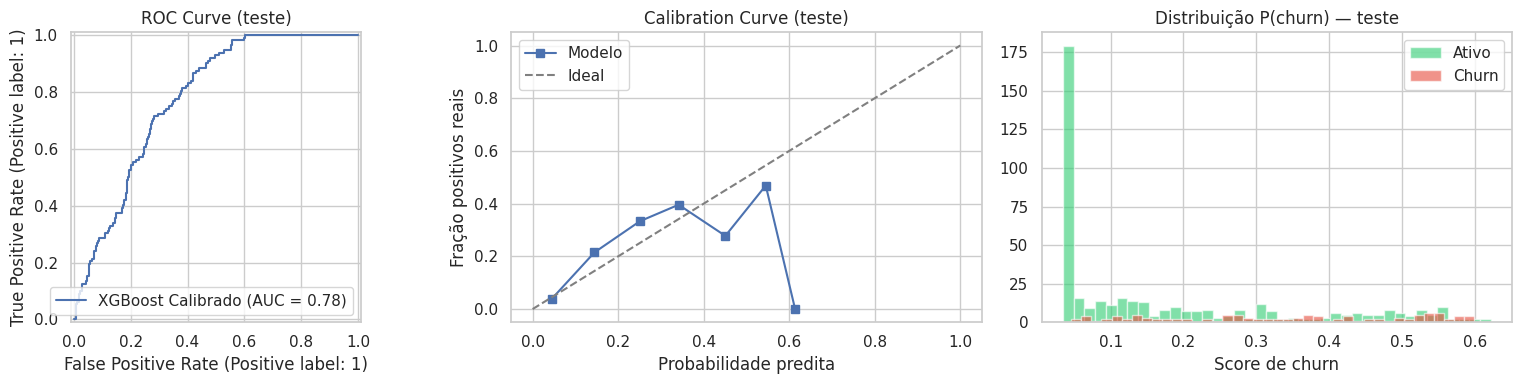

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[0], name='XGBoost Calibrado')
axes[0].set_title('ROC Curve (teste)')

# Calibration curve
fraction_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
axes[1].plot(mean_pred, fraction_pos, 's-', label='Modelo')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Ideal')
axes[1].set_title('Calibration Curve (teste)')
axes[1].set_xlabel('Probabilidade predita')
axes[1].set_ylabel('Fração positivos reais')
axes[1].legend()

# Distribuição do score de churn
axes[2].hist(proba[y_test == 0], bins=40, alpha=0.6, label='Ativo', color='#2ecc71')
axes[2].hist(proba[y_test == 1], bins=40, alpha=0.6, label='Churn', color='#e74c3c')
axes[2].set_title('Distribuição P(churn) — teste')
axes[2].set_xlabel('Score de churn')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'churn_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Precision@K

In [11]:
results_test = pd.DataFrame({
    'customer_id': X_test.index,
    'churn_score': proba,
    'churn_real': y_test.values
}).sort_values('churn_score', ascending=False).reset_index(drop=True)

for k in [50, 100, 150, 200]:
    top_k = results_test.head(k)
    precision = top_k['churn_real'].mean()
    recall = top_k['churn_real'].sum() / y_test.sum()
    print(f'Precision@{k}: {precision:.1%}  |  Recall@{k}: {recall:.1%}')

Precision@50: 46.0%  |  Recall@50: 20.5%
Precision@100: 38.0%  |  Recall@100: 33.9%
Precision@150: 40.7%  |  Recall@150: 54.5%
Precision@200: 39.0%  |  Recall@200: 69.6%


## 8. Feature importance

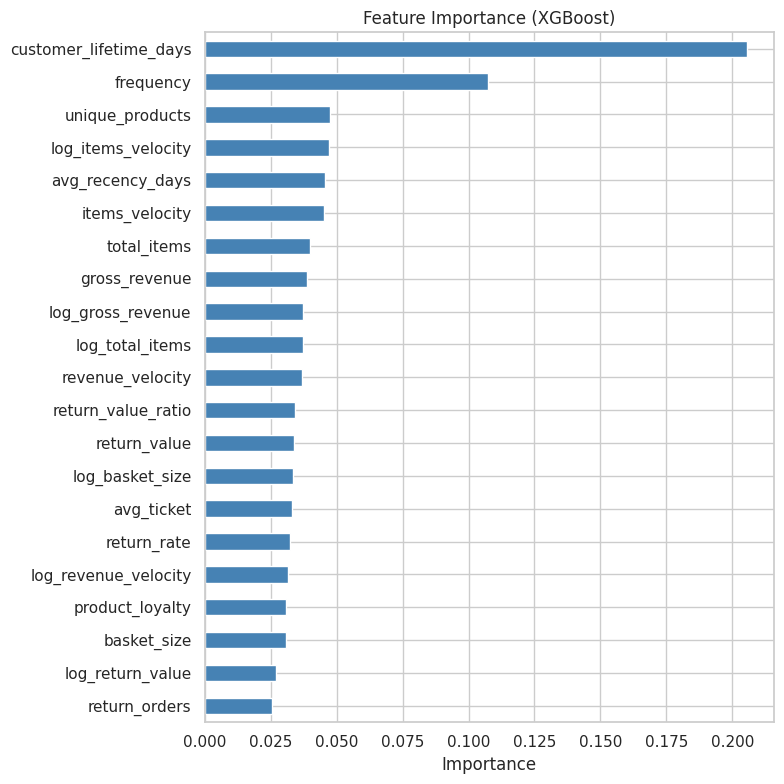

In [12]:
# Extrair importância do estimador base
base_estimator = calibrated_model.calibrated_classifiers_[0].estimator
importance = pd.Series(base_estimator.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'churn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Salvar modelo e scores

In [13]:
joblib.dump(calibrated_model, MODEL_DIR / 'xgb_churn_calibrated.pkl')
print('Modelo salvo em models/churn/xgb_churn_calibrated.pkl')

# Scores para todos os clientes (treino + teste) — usados no A/B e uplift
# X.index contém customer_id real (preservado desde build_features.py)
proba_all = calibrated_model.predict_proba(X)[:, 1]
test_idx = set(X_test.index)
all_scores = pd.DataFrame({
    'customer_id': X.index,
    'churn_score': proba_all,
    'churn_real': y.values,
    'split': ['test' if idx in test_idx else 'train' for idx in X.index]
}).sort_values('churn_score', ascending=False).reset_index(drop=True)

all_scores.to_parquet(PROCESSED_DIR / 'churn_scores.parquet', index=False)
print('Scores salvos em data/processed/churn_scores.parquet')
print(f'customer_ids únicos: {all_scores["customer_id"].nunique()} (esperado: {len(X)})')

Modelo salvo em models/churn/xgb_churn_calibrated.pkl
Scores salvos em data/processed/churn_scores.parquet
customer_ids únicos: 2758 (esperado: 2758)


## 10. Tradução de Negócio

**Cenário simulado:** e-commerce B2C, 4.300 clientes ativos, ticket médio R$ 350.
Campanha de retenção: cupom 10% + e-mail personalizado, custo R$ 15/contato, taxa de retenção estimada 30%.

**Lógica de escolha do threshold:**
- Falso Negativo (FN): cliente que vai churnar e não é contactado → perde-se a receita da próxima compra (~R$ 350)
- Falso Positivo (FP): cliente que ficaria de qualquer jeito e recebe campanha → custo da campanha (-R$ 15)
- Relação de custo FN/FP = **7×** → threshold conservador (0.20) maximiza recall

In [14]:
# ── Premissas da campanha ──────────────────────────────────────────
CUSTO_CONTATO       = 15     # R$ por cliente contactado
TICKET_MEDIO        = 350    # R$ receita por cliente retido
TAXA_RETENCAO       = 0.30   # % de churners que a campanha converte
RETORNO_LIQ_CHURNER = TICKET_MEDIO * TAXA_RETENCAO - CUSTO_CONTATO  # R$90

# ── Escalar resultados do teste para a base completa (2.758 clientes) ─
ESCALA = len(X) / len(X_test)

def get_confusion(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return int(tp), int(fp), int(fn)

cenarios = {
    'Threshold 0.20 (escolhido)': get_confusion(y_test, proba, 0.20),
    'Threshold 0.30':             get_confusion(y_test, proba, 0.30),
    'Sem campanha':               (0, 0, int(y_test.sum())),
}

print(f"{'Cenário':<30} {'Contactados':>11} {'Retidos':>8} {'Receita':>12} {'Custo':>10} {'ROI Líquido':>12}")
print("-" * 88)

for nome, (tp_raw, fp_raw, fn_raw) in cenarios.items():
    tp  = round(tp_raw  * ESCALA)
    fp  = round(fp_raw  * ESCALA)
    contactados = tp + fp
    receita     = tp * RETORNO_LIQ_CHURNER
    custo_fp    = fp * CUSTO_CONTATO
    roi         = receita - custo_fp
    print(f"{nome:<30} {contactados:>11,} {tp:>8,} {receita:>11,.0f} {custo_fp:>9,.0f} {roi:>12,.0f}")

print()
print(f"Retorno líquido por churner retido: R$ {RETORNO_LIQ_CHURNER:.0f}")
print(f"  = ticket médio R${TICKET_MEDIO} × taxa retenção {TAXA_RETENCAO:.0%} − custo R${CUSTO_CONTATO}")
print()
print("→ Threshold 0.20 entrega o maior ROI por contato mais churners de alto valor.")

Cenário                        Contactados  Retidos      Receita      Custo  ROI Líquido
----------------------------------------------------------------------------------------
Threshold 0.20 (escolhido)           1,129      415      37,350    10,710       26,640
Threshold 0.30                         845      320      28,800     7,875       20,925
Sem campanha                             0        0           0         0            0

Retorno líquido por churner retido: R$ 90
  = ticket médio R$350 × taxa retenção 30% − custo R$15

→ Threshold 0.20 entrega o maior ROI por contato mais churners de alto valor.


In [15]:
print('Top 10 clientes em risco:')
all_scores.head(10)

Top 10 clientes em risco:


,customer_id,churn_score,churn_real,split
0,12755,0.655951,1,train
1,12908,0.648056,1,train
2,13791,0.640779,1,train
3,14264,0.636849,1,train
4,18064,0.635150,1,train
5,17854,0.627245,1,train
6,16716,0.625130,1,train
7,17892,0.621768,0,test
8,14195,0.620018,1,train
9,17045,0.619418,1,train
